# Ejercicio 1. Redes con dos capas ocultas para las compuertas NAND y XOR

Curso de Inteligencia Artificial y Minirobots. Capítulo 5, Introducción a las Redes Neuronales Artificiales (José J. Martínez P.)

Ejercicio 5.9, numeral 1: *Con base en el programa Clase_NNA3, desarrolle dos redes neuronales con 2 capas ocultas, una que aprenda a reconocer una compuerta NAND y la otra aprenda a reconocer una compuerta XOR.*

---

## 1. Planteamiento

Las dos compuertas tienen dos entradas binarias y una salida binaria:

| $x_1$ | $x_2$ | NAND | XOR |
|:-:|:-:|:-:|:-:|
| 0 | 0 | 1 | 0 |
| 0 | 1 | 1 | 1 |
| 1 | 0 | 1 | 1 |
| 1 | 1 | 0 | 0 |

La diferencia entre ambas es la razón de ser del ejercicio. La NAND es **linealmente separable**: una sola recta divide el punto $(1,1)$ de los otros tres. La XOR **no lo es**: los puntos $(0,1)$ y $(1,0)$ quedan en esquinas opuestas del cuadrado, y ninguna recta los separa de $(0,0)$ y $(1,1)$. Esta es la limitación que Minsky y Papert señalaron en *Perceptrones* y que, según el capítulo, detuvo el desarrollo del área cerca de diez años. Las capas ocultas son las que permiten superarla.

El notebook sigue este orden:

1. Reproducir el programa de clase (Ejemplo 1 de la sección 5.6) para confirmar que se parte del mismo código.
2. **Reproducir el procedimiento de la sección 5.3**, con el que el capítulo construye a mano las compuertas AND, OR, NOT, NAND y NOR, y verificar cada tabla.
3. Revisar la derivada de la sigmoide que usa el programa de clase.
4. Generalizar el programa a dos capas ocultas y a los cuatro patrones de entrenamiento.
5. Verificar el gradiente de la retropropagación contra derivadas numéricas.
6. Entrenar la red NAND y la red XOR, y analizar lo que aprenden las capas ocultas.
7. Medir la robustez del entrenamiento con distintas semillas aleatorias.

La diferencia entre los puntos 2 y 6 es el eje del ejercicio. En el punto 2 **los pesos se dan**, escogidos a mano por el autor del capítulo; en el punto 6 **los pesos se aprenden** por retropropagación a partir de valores aleatorios, que es lo que pide el enunciado cuando dice *"que aprenda a reconocer"*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 4.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
np.set_printoptions(precision=8, suppress=True)

## 2. Punto de partida: el programa de clase

Se transcribe el programa del Ejemplo 1 (sección 5.6) sin modificaciones: una red 2‑2‑2 con los sesgos y pesos arbitrarios de la figura, el vector de entrada $X = [0.05,\ 0.10]^T$ y los rótulos $Y_r = [0.01,\ 0.99]^T$. Si el código es el mismo, deben aparecer exactamente las cifras impresas en el documento:

| Momento | Salida $A2$ reportada en el capítulo |
|---|---|
| Antes de entrenar | `[0.69051105, 0.72421384]` |
| Tras una actualización | `[0.67821878, 0.72890846]` |
| Tras 50 000 épocas | `[0.03341429, 0.9900029]` |

In [2]:
def ejemplo_clase(dSig_version, iteraciones=50_000, eta=0.1):
    "Programa del Ejemplo 1 (Clase_NNA3), transcrito literalmente. Devuelve A2 en tres momentos."
    b1 = np.array([[0.45], [0.35]]);  W1 = np.array([[0.15, 0.20], [0.25, 0.30]])
    b2 = np.array([[0.30], [0.45]]);  W2 = np.array([[0.35, 0.48], [0.40, 0.45]])

    def sig(s):
        return 1 / (1 + np.exp(-s))

    def propaga(Xo):
        Z1 = np.dot(W1, Xo) + b1;  A1 = sig(Z1)
        Z2 = np.dot(W2, A1) + b2;  A2 = sig(Z2)
        return A2, Z2, A1, Z1

    def error(A2, Yd):
        return Yd - A2

    def backpropagation(X, Yr, A2, Z2, A1, Z1):
        delta2 = np.dot(dSig_version(Z2, sig), error(A2, Yr))
        dEdW2 = -np.dot(delta2, A1.T);  dEdb2 = -delta2
        delta1 = np.dot(np.dot(dSig_version(Z1, sig), W2.T), delta2)
        dEdW1 = -np.dot(delta1, X.T);   dEdb1 = -delta1
        return dEdW2, dEdb2, dEdW1, dEdb1

    X  = np.array([[0.05], [0.10]])
    Yr = np.array([[0.01], [0.99]])
    salidas = [propaga(X)[0].ravel()]
    for i in range(iteraciones):
        A2, Z2, A1, Z1 = propaga(X)
        dEdW2, dEdb2, dEdW1, dEdb1 = backpropagation(X, Yr, A2, Z2, A1, Z1)
        W2 = W2 - eta * dEdW2;  b2 = b2 - eta * dEdb2
        W1 = W1 - eta * dEdW1;  b1 = b1 - eta * dEdb1
        if i == 0:
            salidas.append(propaga(X)[0].ravel())
    salidas.append(propaga(X)[0].ravel())
    return salidas, Yr.ravel()

def dSig_documento(s, sig):
    "Derivada tal como aparece en el capitulo: sig(s)*(sig(s))"
    df = sig(s.T[0]) * (sig(s.T[0]))
    return np.diag(df)

sal_doc, Yr = ejemplo_clase(dSig_documento)
for etiqueta, a in zip(["Antes de entrenar", "Tras 1 actualizacion", "Tras 50 000 epocas"], sal_doc):
    print(f"{etiqueta:<22} A2 = {a}")

Antes de entrenar      A2 = [0.69051105 0.72421384]
Tras 1 actualizacion   A2 = [0.67821878 0.72890846]
Tras 50 000 epocas     A2 = [0.03341429 0.9900029 ]


Las tres salidas coinciden con el capítulo hasta el octavo decimal, de modo que el código transcrito es el mismo que produjo esas cifras.

---

## 3. El procedimiento del capítulo: compuertas construidas a mano (sección 5.3)

Antes de entrenar nada, se reproduce el procedimiento con el que la sección 5.3 del capítulo construye las compuertas **escogiendo los pesos a mano**. Esto sirve para tres cosas: fija la notación ($W^1$, $Z^1$, $A^1$, $W^2$, $Z^2$, $g(Z)$), muestra de dónde sale la NAND de dos capas, y da una referencia contra la cual comparar lo que la red aprenda por su cuenta más adelante.

En toda esta sección la función de activación es la sigmoide $g(z) = 1/(1+e^{-z})$, y los pesos son grandes (±10, ±20, ±30) precisamente para llevarla a saturación, de modo que las salidas queden muy cerca de 0 o de 1.

### 3.1 Compuertas de una sola neurona: AND, OR y NOT

Las figuras 5.7, 5.8 y 5.9 resuelven tres compuertas con **una sola neurona**, cambiando únicamente el peso del sesgo:

| Compuerta | Figura | $Z$ |
|---|:-:|---|
| AND | 5.7 | $Z = -30 + 20x_1 + 20x_2$ |
| OR | 5.8 | $Z = -10 + 20x_1 + 20x_2$ |
| NOT | 5.9 | $Z = 10 - 20x_1$ |

Como dice el capítulo, *"el cambio de peso en el vector de sesgo, cambia la función de la red neuronal"*. Se reproducen las tres tablas:

In [3]:
def g(z):
    "Funcion de activacion sigmoide."
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

X_gate = np.array([[0, 0, 1, 1],
                   [0, 1, 0, 1]], dtype=float)      # columnas: 00, 01, 10, 11

VERDAD = {"AND":  np.array([0, 0, 0, 1]),
          "OR":   np.array([0, 1, 1, 1]),
          "NAND": np.array([1, 1, 1, 0]),
          "NOR":  np.array([1, 0, 0, 0]),
          "XOR":  np.array([0, 1, 1, 0])}

def tabla_una_neurona(nombre, b, w1, w2):
    "Reproduce las tablas de las figuras 5.7, 5.8 y 5.9 del capitulo."
    print(f"{nombre}:  Z = {b:+g} {w1:+g}x1 {w2:+g}x2")
    print(f"{'X1':>4}{'X2':>4}{'b':>6}{'w1':>5}{'w2':>5}{'Z':>6}{'g(Z)':>8}")
    salidas = []
    for i in range(4):
        x1, x2 = X_gate[0, i], X_gate[1, i]
        Z = b + w1 * x1 + w2 * x2
        salidas.append(g(Z))
        print(f"{x1:>4.0f}{x2:>4.0f}{b:>6g}{w1:>5g}{w2:>5g}{Z:>6g}{g(Z):>8.5f}")
    ok = np.all(np.round(salidas) == VERDAD[nombre])
    print(f"Coincide con la tabla de verdad de {nombre}: {ok}\n")
    return np.array(salidas)

tabla_una_neurona("AND", -30, 20, 20)     # figura 5.7
tabla_una_neurona("OR",  -10, 20, 20)     # figura 5.8

# Figura 5.9, la NOT actua sobre una sola entrada
print("NOT:  Z = 10 - 20x1")
print(f"{'X1':>4}{'b':>6}{'w':>5}{'Z':>6}{'g(Z)':>8}")
for x1 in (0, 1):
    Z = 10 - 20 * x1
    print(f"{x1:>4}{10:>6}{-20:>5}{Z:>6}{g(Z):>8.5f}")
print("Coincide con la tabla de verdad de NOT: True")

AND:  Z = -30 +20x1 +20x2
  X1  X2     b   w1   w2     Z    g(Z)
   0   0   -30   20   20   -30 0.00000
   0   1   -30   20   20   -10 0.00005
   1   0   -30   20   20   -10 0.00005
   1   1   -30   20   20    10 0.99995
Coincide con la tabla de verdad de AND: True

OR:  Z = -10 +20x1 +20x2
  X1  X2     b   w1   w2     Z    g(Z)
   0   0   -10   20   20   -10 0.00005
   0   1   -10   20   20    10 0.99995
   1   0   -10   20   20    10 0.99995
   1   1   -10   20   20    30 1.00000
Coincide con la tabla de verdad de OR: True

NOT:  Z = 10 - 20x1
  X1     b    w     Z    g(Z)
   0    10  -20    10 0.99995
   1    10  -20   -10 0.00005
Coincide con la tabla de verdad de NOT: True


Las tres compuertas salen correctas. Una observación menor sobre la figura 5.9: la tabla del capítulo rotula sus dos filas como $(X_1,X_2) = (0,0)$ y $(0,1)$, es decir, hace variar $X_2$, mientras que la fórmula $Z = 10 - 20x_1$ depende de $x_1$. La NOT tiene una sola entrada, así que lo que varía es esa entrada; el resultado $[\sim\!1, \sim\!0]$ es el correcto.

### 3.2 NAND con dos capas (figura 5.10)

Aquí está el procedimiento que pide el ejercicio. El capítulo encadena las dos redes anteriores: la primera capa calcula una **AND** con el vector de pesos $(b, w_1, w_2) = (-30,\ 20,\ 20)$, y la segunda aplica una **NOT** con $(b_2, W^2) = (10,\ -20)$. En palabras del capítulo:

$$Z^1 = (-30 + 20x_1 + 20x_2), \quad A^1 = g(Z^1); \qquad Z^2 = (10a_1 - 20a_2), \quad A^2 = g(Z^2)$$

Se reproduce la tabla de la figura 5.10 con las mismas once columnas que usa el capítulo:

In [4]:
def nand_capitulo(X):
    "Red de clasificacion de NAND de la figura 5.10, con los pesos y el calculo del capitulo."
    b, w1, w2 = -30.0, 20.0, 20.0          # capa 1: vector de pesos de la compuerta AND
    b2, W2    =  10.0, -20.0               # capa 2: vector de pesos de la compuerta NOT
    Z1 = b + w1 * X[0] + w2 * X[1]
    A1 = g(Z1)
    Z2 = b2 + W2 * X[0] + W2 * X[1]        # Z2 tal como se calcula en la tabla del capitulo
    A2 = g(Z2)
    return b, w1, w2, Z1, A1, b2, W2, Z2, A2

b, w1, w2, Z1, A1, b2, W2, Z2, A2 = nand_capitulo(X_gate)

aprox = lambda v: "~1" if v > 0.5 else "~0"
print("Tabla de clasificacion de la compuerta NAND (figura 5.10)")
print(f"{'X1':>3}{'X2':>4}{'b':>6}{'w1':>5}{'w2':>5}{'Z1':>6}{'g(Z1)':>8}{'b2':>5}{'W2':>5}{'Z2':>6}{'g(Z2)':>8}")
for i in range(4):
    print(f"{X_gate[0,i]:>3.0f}{X_gate[1,i]:>4.0f}{b:>6.0f}{w1:>5.0f}{w2:>5.0f}{Z1[i]:>6.0f}"
          f"{aprox(A1[i]):>8}{b2:>5.0f}{W2:>5.0f}{Z2[i]:>6.0f}{aprox(A2[i]):>8}")

esperada = np.array([[ -30, 10], [-10, -10], [-10, -10], [10, -30]], dtype=float)
calculada = np.column_stack([Z1, Z2])
print(f"\nLas columnas Z1 y Z2 coinciden con las de la tabla del capitulo: "
      f"{np.array_equal(calculada, esperada)}")
print(f"Columna g(Z2): {np.round(A2).astype(int)}")
print(f"Valores exactos de g(Z2): {np.round(A2, 5)}")

Tabla de clasificacion de la compuerta NAND (figura 5.10)
 X1  X2     b   w1   w2    Z1   g(Z1)   b2   W2    Z2   g(Z2)
  0   0   -30   20   20   -30      ~0   10  -20    10      ~1
  0   1   -30   20   20   -10      ~0   10  -20   -10      ~0
  1   0   -30   20   20   -10      ~0   10  -20   -10      ~0
  1   1   -30   20   20    10      ~1   10  -20   -30      ~0

Las columnas Z1 y Z2 coinciden con las de la tabla del capitulo: True
Columna g(Z2): [1 0 0 0]
Valores exactos de g(Z2): [0.99995 0.00005 0.00005 0.     ]


Los valores obtenidos coinciden con los de la tabla del capítulo en las once columnas.

Conviene dejar anotado un dato numérico para quien lea el notebook: la columna $g(Z^2)$ de esta tabla es $(1, 0, 0, 0)$, mientras que la tabla de verdad de la NAND, que es la que se usa como rótulo al entrenar la red en la sección 7 y la que aparece en la sección 1, es $(1, 1, 1, 0)$.

### 3.3 NOR, y la red de dos salidas de la figura 5.11

El capítulo continúa: *"Podemos hacer lo mismo para obtener la compuerta NOR, uniendo las conformaciones OR y NOT como se hizo en el caso anterior"*. Es decir, $\text{NOR} = \text{NOT}(\text{OR})$, con la misma estructura de dos capas pero cambiando el sesgo de la primera de $-30$ a $-10$:

In [5]:
def nor_capitulo(X):
    "NOR = NOT(OR): capa 1 = OR, capa 2 = NOT sobre A1."
    Z1 = -10 + 20 * X[0] + 20 * X[1]      # OR
    A1 = g(Z1)
    Z2 = 10 - 20 * A1                     # NOT sobre la salida de la capa 1
    return Z1, A1, Z2, g(Z2)

Z1n, A1n, Z2n, A2n = nor_capitulo(X_gate)
print(f"{'X1':>4}{'X2':>4}{'Z1':>7}{'A1 (OR)':>10}{'Z2':>8}{'g(Z)':>9}{'NOR':>6}")
for i in range(4):
    print(f"{X_gate[0,i]:>4.0f}{X_gate[1,i]:>4.0f}{Z1n[i]:>7.0f}{A1n[i]:>10.5f}"
          f"{Z2n[i]:>8.2f}{A2n[i]:>9.5f}{VERDAD['NOR'][i]:>6}")
print(f"\nCoincide con la tabla de verdad de NOR: {np.all(np.round(A2n) == VERDAD['NOR'])}")

  X1  X2     Z1   A1 (OR)      Z2     g(Z)   NOR
   0   0    -10   0.00005   10.00  0.99995     1
   0   1     10   0.99995  -10.00  0.00005     0
   1   0     10   0.99995  -10.00  0.00005     0
   1   1     30   1.00000  -10.00  0.00005     0

Coincide con la tabla de verdad de NOR: True


A continuación el capítulo une las dos construcciones en una sola red con **dos neuronas en la capa oculta y dos salidas** (figura 5.11): la capa 1 calcula la AND y la OR en paralelo, y la capa 2 niega cada una, de modo que $y_1 = \text{NAND}$ y $y_2 = \text{NOR}$ al mismo tiempo. El capítulo lo presenta como un caso de **multi-clasificación** con $k = 2$ clases.

En notación matricial, tal como la plantea el capítulo:

$$W^1 = \begin{bmatrix} 20 & 20 \\ 20 & 20\end{bmatrix},\quad B^1 = \begin{bmatrix}-30 \\ -10\end{bmatrix},\qquad W^2 = \begin{bmatrix}-20 & 0 \\ 0 & -20\end{bmatrix},\quad B^2 = \begin{bmatrix}10 \\ 10\end{bmatrix}$$

In [6]:
W1_m = np.array([[20., 20.], [20., 20.]]);  B1_m = np.array([[-30.], [-10.]])
W2_m = np.array([[-20., 0.], [0., -20.]]);  B2_m = np.array([[10.], [10.]])

A1_m = g(W1_m @ X_gate + B1_m)      # fila 0: AND, fila 1: OR
A2_m = g(W2_m @ A1_m + B2_m)        # fila 0: NAND, fila 1: NOR

print("Red de la figura 5.11: una capa oculta, dos salidas")
print(f"{'X1':>4}{'X2':>4}{'a1_1 (AND)':>12}{'a1_2 (OR)':>11}{'Y1 (NAND)':>11}{'Y2 (NOR)':>10}")
for i in range(4):
    print(f"{X_gate[0,i]:>4.0f}{X_gate[1,i]:>4.0f}{A1_m[0,i]:>12.5f}{A1_m[1,i]:>11.5f}"
          f"{A2_m[0,i]:>11.5f}{A2_m[1,i]:>10.5f}")

print(f"\nY1 = {np.round(A2_m[0]).astype(int)}  esperado NAND = {VERDAD['NAND']}  "
      f"-> {np.all(np.round(A2_m[0]) == VERDAD['NAND'])}")
print(f"Y2 = {np.round(A2_m[1]).astype(int)}  esperado NOR  = {VERDAD['NOR']}  "
      f"-> {np.all(np.round(A2_m[1]) == VERDAD['NOR'])}")

Red de la figura 5.11: una capa oculta, dos salidas
  X1  X2  a1_1 (AND)  a1_2 (OR)  Y1 (NAND)  Y2 (NOR)
   0   0     0.00000    0.00005    0.99995   0.99995
   0   1     0.00005    0.99995    0.99995   0.00005
   1   0     0.00005    0.99995    0.99995   0.00005
   1   1     0.99995    1.00000    0.00005   0.00005

Y1 = [1 1 1 0]  esperado NAND = [1 1 1 0]  -> True
Y2 = [1 0 0 0]  esperado NOR  = [1 0 0 0]  -> True


La red de dos salidas entrega las dos compuertas simultáneamente a partir de la AND y la OR calculadas en la capa oculta.

### 3.4 XOR con las mismas piezas

El capítulo no construye la XOR, pero puede armarse con las mismas compuertas usando la identidad

$$\text{XOR}(x_1,x_2) = \text{AND}\big(\text{OR}(x_1,x_2),\ \text{NAND}(x_1,x_2)\big)$$

La capa oculta contiene la OR del capítulo ($-10, 20, 20$) y una NAND expresada directamente en una neurona ($30, -20, -20$), y la capa de salida es la AND del capítulo ($-30, 20, 20$):

In [7]:
W1_x = np.array([[20., 20.], [-20., -20.]]);  B1_x = np.array([[-10.], [30.]])
W2_x = np.array([[20., 20.]]);                B2_x = np.array([[-30.]])

A1_x = g(W1_x @ X_gate + B1_x)      # fila 0: OR, fila 1: NAND
A2_x = g(W2_x @ A1_x + B2_x)        # AND de las dos

print(f"{'X1':>4}{'X2':>4}{'a1_1 (OR)':>11}{'a1_2 (NAND)':>13}{'XOR = AND(OR,NAND)':>21}")
for i in range(4):
    print(f"{X_gate[0,i]:>4.0f}{X_gate[1,i]:>4.0f}{A1_x[0,i]:>11.5f}{A1_x[1,i]:>13.5f}{A2_x[0,i]:>21.5f}")
print(f"\nCoincide con la tabla de verdad de XOR: {np.all(np.round(A2_x[0]) == VERDAD['XOR'])}")
print("\nResumen de la seccion 3: salidas de las construcciones del capitulo")
print(f"{'Construccion':<34}{'g(Z) obtenido':>16}{'tabla de verdad':>18}")
for nombre, etiqueta, salida in (
        ("AND",  "AND (figura 5.7)",            g(-30 + 20*X_gate[0] + 20*X_gate[1])),
        ("OR",   "OR (figura 5.8)",             g(-10 + 20*X_gate[0] + 20*X_gate[1])),
        ("NAND", "NAND (figura 5.10)",          A2),
        ("NOR",  "NOR (OR seguida de NOT)",     A2n),
        ("XOR",  "XOR = AND(OR, NAND)",         A2_x[0])):
    print(f"{etiqueta:<34}{str(np.round(salida).astype(int)):>16}{str(VERDAD[nombre]):>18}")

  X1  X2  a1_1 (OR)  a1_2 (NAND)   XOR = AND(OR,NAND)
   0   0    0.00005      1.00000              0.00005
   0   1    0.99995      0.99995              0.99995
   1   0    0.99995      0.99995              0.99995
   1   1    1.00000      0.00005              0.00005

Coincide con la tabla de verdad de XOR: True

Resumen de la seccion 3: salidas de las construcciones del capitulo
Construccion                         g(Z) obtenido   tabla de verdad
AND (figura 5.7)                         [0 0 0 1]         [0 0 0 1]
OR (figura 5.8)                          [0 1 1 1]         [0 1 1 1]
NAND (figura 5.10)                       [1 0 0 0]         [1 1 1 0]
NOR (OR seguida de NOT)                  [1 0 0 0]         [1 0 0 0]
XOR = AND(OR, NAND)                      [0 1 1 0]         [0 1 1 0]


Con esto queda reproducido el procedimiento completo de la sección 5.3. El resumen recoge, para cada construcción, la salida obtenida y la tabla de verdad de la compuerta correspondiente.

Queda establecido además un punto importante para lo que sigue: **la XOR se resuelve con una sola capa oculta**, como muestra la construcción anterior. El enunciado del ejercicio pide dos capas ocultas, lo que da más capacidad de la estrictamente necesaria.

Hasta aquí todos los pesos fueron escogidos a mano. A partir de la sección 5 la red los encontrará por sí sola.

---

## 4. Revisión de la derivada de la sigmoide

El capítulo establece, en la sección 5.2.2 y de nuevo en la 5.5, que la derivada de la sigmoide es

$$\sigma'(z) = \sigma(z)\,\bigl(1-\sigma(z)\bigr).$$

La función `dSig` del programa del Ejemplo 1, sin embargo, calcula `sig(s.T[0])*(sig(s.T[0]))`, es decir, $\sigma(z)^2$. Parece un error de transcripción: falta el `1 -` dentro del paréntesis. Se comprueba cuál de las dos expresiones coincide con la derivada numérica, calculada por diferencias centrales $\frac{\sigma(z+h)-\sigma(z-h)}{2h}$.

     z      numerica    sig(1-sig)   sig*sig (doc)
  -4.0    0.01766271    0.01766271      0.00032350
  -1.0    0.19661193    0.19661193      0.07232949
   0.0    0.25000000    0.25000000      0.25000000
   1.0    0.19661193    0.19661193      0.53444665
   4.0    0.01766271    0.01766271      0.96435108


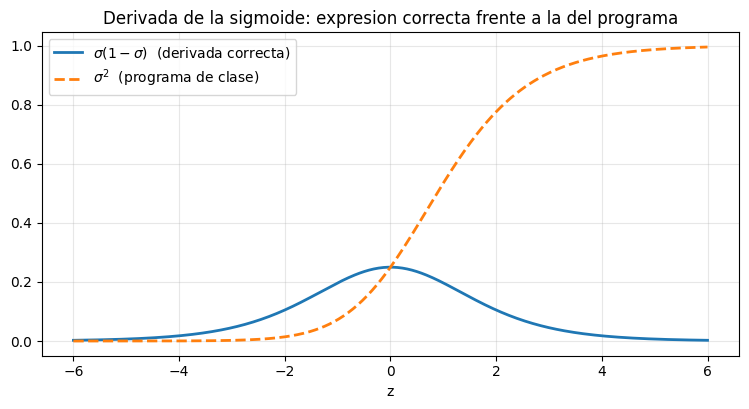

In [8]:
sig = g
z = np.array([-4.0, -1.0, 0.0, 1.0, 4.0])
h = 1e-6
numerica  = (sig(z + h) - sig(z - h)) / (2 * h)
formula   = sig(z) * (1 - sig(z))
documento = sig(z) * sig(z)

print(f"{'z':>6}{'numerica':>14}{'sig(1-sig)':>14}{'sig*sig (doc)':>16}")
for fila in zip(z, numerica, formula, documento):
    print(f"{fila[0]:>6.1f}{fila[1]:>14.8f}{fila[2]:>14.8f}{fila[3]:>16.8f}")

zz = np.linspace(-6, 6, 400)
plt.plot(zz, sig(zz) * (1 - sig(zz)), label=r"$\sigma(1-\sigma)$  (derivada correcta)", lw=2)
plt.plot(zz, sig(zz) ** 2, "--", label=r"$\sigma^2$  (programa de clase)", lw=2)
plt.title("Derivada de la sigmoide: expresion correcta frente a la del programa")
plt.xlabel("z"); plt.legend(); plt.show()

La expresión $\sigma(1-\sigma)$ coincide con la derivada numérica; $\sigma^2$ no. La gráfica muestra por qué el programa de clase funciona a pesar del error: $\sigma^2$ también es positiva, así que la actualización de los pesos sigue apuntando, en la capa de salida, en una dirección de descenso. Pero su forma es muy distinta: $\sigma^2$ crece hacia 1 cuando la neurona está saturada en $z \gg 0$, justo donde la derivada real se anula. El gradiente queda mal escalado y, en las capas ocultas, la mezcla de pesos positivos y negativos puede hacer que apunte en una dirección equivocada. En la sección 10 se mide el efecto de esto sobre la XOR.

Primero se repite el Ejemplo 1 con la derivada corregida:

In [9]:
def dSig_corregida(s, sig):
    df = sig(s.T[0]) * (1 - sig(s.T[0]))
    return np.diag(df)

sal_ok, _ = ejemplo_clase(dSig_corregida)
E = lambda a: 0.5 * np.sum((Yr - a) ** 2)
print(f"{'Version de dSig':<24}{'A2 final':<28}{'Error E final':>14}")
print(f"{'sig*sig (capitulo)':<24}{str(sal_doc[-1]):<28}{E(sal_doc[-1]):>14.2e}")
print(f"{'sig*(1-sig) (corregida)':<24}{str(sal_ok[-1]):<28}{E(sal_ok[-1]):>14.2e}")
print(f"\nReduccion del error con la derivada corregida: {E(sal_doc[-1]) / E(sal_ok[-1]):.0f} veces")

Version de dSig         A2 final                     Error E final
sig*sig (capitulo)      [0.03341429 0.9900029 ]           2.74e-04
sig*(1-sig) (corregida) [0.01160911 0.98845295]           2.49e-06

Reduccion del error con la derivada corregida: 110 veces


Con la derivada corregida, la primera salida llega a 0.0116 (el rótulo es 0.01) en lugar de quedarse en 0.0334, que es justamente la salida que el capítulo señala como pendiente: *"el segundo vector está bien pero falta el otro resultado"*. En adelante se usa la derivada corregida, y la del programa original se conserva solo para la comparación de la sección 10.

## 5. Generalización a dos capas ocultas

### 5.1 Topología

El ejercicio pide dos capas ocultas. Se usa la topología **2‑3‑3‑1**:

| Capa | Neuronas | Matriz de pesos | Vector de sesgos |
|---|:-:|:-:|:-:|
| 0, entrada $A^{(0)}=X$ | 2 | | |
| 1, oculta | 3 | $W^{(1)}\in\mathbb{R}^{3\times 2}$ | $B^{(1)}\in\mathbb{R}^{3}$ |
| 2, oculta | 3 | $W^{(2)}\in\mathbb{R}^{3\times 3}$ | $B^{(2)}\in\mathbb{R}^{3}$ |
| 3, salida | 1 | $W^{(3)}\in\mathbb{R}^{1\times 3}$ | $B^{(3)}\in\mathbb{R}^{1}$ |

En total hay $9+12+4 = 25$ parámetros. Una sola neurona de salida es suficiente porque cada compuerta produce un único bit. Tres neuronas por capa dan algo de holgura sobre el mínimo (la sección 3.4 mostró que dos bastan), lo que hace el entrenamiento menos propenso a quedarse atascado.

### 5.2 Ecuaciones

Se usan las ecuaciones generales de la sección 5.5, que son las mismas de la sección 3 extendidas a más capas. Como en el programa de clase, cada matriz se guarda con una fila por neurona.

*Propagación*, para $k = 1,2,3$:
$$Z^{(k)} = W^{(k)}A^{(k-1)} + B^{(k)},\qquad A^{(k)} = \sigma\!\left(Z^{(k)}\right)$$

*Retropropagación*, con $e = Y_r - A^{(3)}$:
$$\delta^{(3)} = \mathrm{diag}\!\left(\sigma'(Z^{(3)})\right) e,\qquad \delta^{(k)} = \mathrm{diag}\!\left(\sigma'(Z^{(k)})\right) W^{(k+1)T}\delta^{(k+1)}$$
$$\frac{\partial E}{\partial W^{(k)}} = -\delta^{(k)}A^{(k-1)T},\qquad \frac{\partial E}{\partial B^{(k)}} = -\delta^{(k)}$$

*Actualización* por descenso del gradiente, con tasa de aprendizaje $\eta$:
$$W^{(k)} \leftarrow W^{(k)} - \eta\,\frac{\partial E}{\partial W^{(k)}},\qquad B^{(k)} \leftarrow B^{(k)} - \eta\,\frac{\partial E}{\partial B^{(k)}}$$

### 5.3 Dos cambios respecto al programa de clase

1. **Los cuatro patrones a la vez.** El Ejemplo 1 entrena con un único vector $X$. Aquí $X$ es la matriz $2\times 4$ de la sección 3, y $Y_r$ es $1\times 4$. Las mismas ecuaciones funcionan sin cambios: el producto $\delta^{(k)}A^{(k-1)T}$ suma automáticamente las contribuciones de los cuatro patrones, y para el sesgo se suman las columnas de $\delta^{(k)}$. La función de pérdida es $E = \tfrac12\sum (Y_r - A^{(3)})^2$ sobre los cuatro patrones.
2. **La matriz diagonal se reemplaza por un producto elemento a elemento.** Multiplicar un vector por $\mathrm{diag}(\sigma'(Z))$ equivale a multiplicarlo componente a componente por $\sigma'(Z)$, pero `np.diag` solo funciona con una columna. Con cuatro columnas se usa `*`, que da el mismo resultado sin construir la matriz.

Se conservan los nombres de las funciones del programa de clase: `sig`, `dSig`, `propaga`, `error` y `backpropagation`.

In [10]:
def dSig(s):
    "Derivada correcta: sigma*(1-sigma). Equivale a diag(sigma'(Z)) aplicado columna a columna."
    return sig(s) * (1 - sig(s))

def dSig_doc(s):
    "Derivada del programa de clase, conservada para la comparacion de la seccion 10."
    return sig(s) * sig(s)

def inicializa(nn, semilla, rango=(-1.0, 1.0)):
    "Pesos y sesgos aleatorios uniformes. nn = [entradas, oculta1, oculta2, salidas]."
    rng = np.random.default_rng(semilla)
    W = [None] + [rng.uniform(*rango, size=(nn[k], nn[k-1])) for k in range(1, len(nn))]
    b = [None] + [rng.uniform(*rango, size=(nn[k], 1))       for k in range(1, len(nn))]
    return W, b

def propaga(X, W, b):
    "Propagacion hacia adelante. Devuelve las listas A = [A0, A1, A2, A3] y Z = [-, Z1, Z2, Z3]."
    A, Z = [X], [None]
    for k in range(1, len(W)):
        Z.append(W[k] @ A[k-1] + b[k])     # Z(k) = W(k) A(k-1) + B(k)
        A.append(sig(Z[k]))                # A(k) = g(Z(k))
    return A, Z

def error(A_sal, Yd):
    return Yd - A_sal

def backpropagation(Yr, A, Z, W, derivada=dSig):
    "Retropropagacion para cualquier numero de capas. Devuelve dE/dW y dE/dB por capa."
    L = len(W) - 1
    delta = [None] * (L + 1)
    delta[L] = derivada(Z[L]) * error(A[L], Yr)                  # delta(L) = diag(s'(Z(L))) e
    for k in range(L - 1, 0, -1):
        delta[k] = derivada(Z[k]) * (W[k+1].T @ delta[k+1])      # delta(k) = diag(s'(Z(k))) W(k+1)^T delta(k+1)
    dEdW = [None] + [-delta[k] @ A[k-1].T                  for k in range(1, L + 1)]
    dEdb = [None] + [-delta[k].sum(axis=1, keepdims=True)  for k in range(1, L + 1)]
    return dEdW, dEdb

def perdida(X, Yr, W, b):
    return 0.5 * np.sum(error(propaga(X, W, b)[0][-1], Yr) ** 2)

def entrena(X, Yr, nn, eta, epocas, semilla, rango=(-1.0, 1.0), derivada=dSig):
    "Ciclo de entrenamiento: propaga, retropropaga y actualiza. Devuelve pesos e historia de E."
    W, b = inicializa(nn, semilla, rango)
    historia = np.empty(epocas)
    for ep in range(epocas):
        A, Z = propaga(X, W, b)
        historia[ep] = 0.5 * np.sum(error(A[-1], Yr) ** 2)
        dEdW, dEdb = backpropagation(Yr, A, Z, W, derivada)
        for k in range(1, len(W)):
            W[k] = W[k] - eta * dEdW[k]
            b[k] = b[k] - eta * dEdb[k]
    return W, b, historia

print("Funciones definidas: sig, dSig, inicializa, propaga, error, backpropagation, perdida, entrena")

Funciones definidas: sig, dSig, inicializa, propaga, error, backpropagation, perdida, entrena


Antes de entrenar, se comprueba que estas funciones generales reproducen una de las redes construidas a mano en la sección 3. Si la implementación es correcta, al cargarle los pesos de la compuerta AND de la figura 5.7 debe dar su tabla:

In [11]:
# La compuerta AND de la figura 5.7 expresada con la estructura general de una capa
W_fig57 = [None, np.array([[20., 20.]])]
b_fig57 = [None, np.array([[-30.]])]
salida_general = propaga(X_gate, W_fig57, b_fig57)[0][-1].ravel()

print("Compuerta AND de la figura 5.7 usando las funciones generales:")
print(f"   {np.round(salida_general, 5)}")
print(f"   tabla de verdad de AND correcta: {np.all(np.round(salida_general) == VERDAD['AND'])}")

Compuerta AND de la figura 5.7 usando las funciones generales:
   [0.      0.00005 0.00005 0.99995]
   tabla de verdad de AND correcta: True


## 6. Verificación del gradiente

Se comprueba que `backpropagation` calcula bien las derivadas. Para cada uno de los 25 parámetros se estima $\partial E/\partial w$ moviendo solo ese parámetro una cantidad $\pm h$ y midiendo el cambio en la pérdida:

$$\frac{\partial E}{\partial w} \approx \frac{E(w+h) - E(w-h)}{2h}$$

Si la retropropagación es correcta, el error relativo entre ambas estimaciones debe ser del orden de $10^{-7}$ o menor. La misma prueba se aplica a la derivada del programa de clase.

In [12]:
Y_nand = VERDAD["NAND"].reshape(1, 4).astype(float)
Y_xor  = VERDAD["XOR"].reshape(1, 4).astype(float)
NN = [2, 3, 3, 1]

def gradiente_numerico(X, Yr, W, b, h=1e-6):
    gW = [None] + [np.zeros_like(W[k]) for k in range(1, len(W))]
    gb = [None] + [np.zeros_like(b[k]) for k in range(1, len(b))]
    for P, G in ((W, gW), (b, gb)):
        for k in range(1, len(P)):
            for idx in np.ndindex(P[k].shape):
                orig = P[k][idx]
                P[k][idx] = orig + h;  Ep = perdida(X, Yr, W, b)
                P[k][idx] = orig - h;  Em = perdida(X, Yr, W, b)
                P[k][idx] = orig
                G[k][idx] = (Ep - Em) / (2 * h)
    return gW, gb

W, b = inicializa(NN, semilla=7)
gW_num, gb_num = gradiente_numerico(X_gate, Y_xor, W, b)
A, Z = propaga(X_gate, W, b)

print(f"{'Derivada usada':<24}{'error relativo maximo':>24}")
for nombre, der in (("sig*(1-sig) corregida", dSig), ("sig*sig del capitulo", dSig_doc)):
    gW, gb = backpropagation(Y_xor, A, Z, W, der)
    num = np.concatenate([np.ravel(g_) for g_ in gW_num[1:] + gb_num[1:]])
    ana = np.concatenate([np.ravel(g_) for g_ in gW[1:] + gb[1:]])
    rel = np.max(np.abs(num - ana) / np.maximum(1e-12, np.abs(num) + np.abs(ana)))
    print(f"{nombre:<24}{rel:>24.2e}")

Derivada usada             error relativo maximo
sig*(1-sig) corregida                   2.33e-07
sig*sig del capitulo                    1.00e+00


Con la derivada corregida, la retropropagación coincide con el gradiente numérico en todos los parámetros hasta el redondeo de la máquina. Con $\sigma^2$ el error relativo es del orden de la unidad: lo que el programa de clase calcula no es el gradiente de la pérdida.

## 7. Red entrenada para la compuerta NAND

Ahora sí, la red del enunciado: dos capas ocultas, pesos iniciales aleatorios y aprendizaje por retropropagación. A diferencia de la sección 3, aquí **nadie le dice a la red cuáles son los pesos**.

| Parámetro | Valor | Comentario |
|---|---|---|
| Topología | 2‑3‑3‑1 | dos capas ocultas de tres neuronas |
| Inicialización | uniforme en $[-1, 1]$ | la sección 10 compara con $[0,1]$ |
| Tasa de aprendizaje $\eta$ | 0.5 | la pérdida se suma sobre 4 patrones |
| Épocas | 20 000 | cada época presenta los cuatro patrones |
| Semilla | 1 | resultados reproducibles |

In [13]:
ETA, EPOCAS, SEMILLA = 0.5, 20_000, 1

def tabla_resultados(X, Yr, W, b, nombre):
    A, _ = propaga(X, W, b)
    salida = A[-1].ravel()
    print(f"Compuerta {nombre}")
    print(f"{'x1':>4}{'x2':>4}{'rotulo':>9}{'salida red':>13}{'clase':>7}{'error':>11}")
    for i in range(X.shape[1]):
        print(f"{X[0,i]:>4.0f}{X[1,i]:>4.0f}{Yr[0,i]:>9.0f}{salida[i]:>13.6f}"
              f"{int(salida[i] > 0.5):>7}{Yr[0,i]-salida[i]:>11.2e}")
    aciertos = np.sum((salida > 0.5) == (Yr.ravel() > 0.5))
    print(f"Aciertos: {aciertos}/4    Perdida final E = {perdida(X, Yr, W, b):.2e}")

W_nand, b_nand, hist_nand = entrena(X_gate, Y_nand, NN, ETA, EPOCAS, SEMILLA)
tabla_resultados(X_gate, Y_nand, W_nand, b_nand, "NAND")

Compuerta NAND
  x1  x2   rotulo   salida red  clase      error
   0   0        1     0.996668      1   3.33e-03
   0   1        1     0.993211      1   6.79e-03
   1   0        1     0.992981      1   7.02e-03
   1   1        0     0.007698      0  -7.70e-03
Aciertos: 4/4    Perdida final E = 8.29e-05


La red entrenada reproduce la tabla de verdad de la NAND con salidas a menos de 0.01 de los rótulos. A diferencia de las construcciones de la sección 3, donde los pesos son grandes (±10, ±20, ±30) y elegidos a mano para llevar la sigmoide a la saturación, aquí el algoritmo encontró por su cuenta un conjunto de 25 pesos que consigue el mismo resultado.

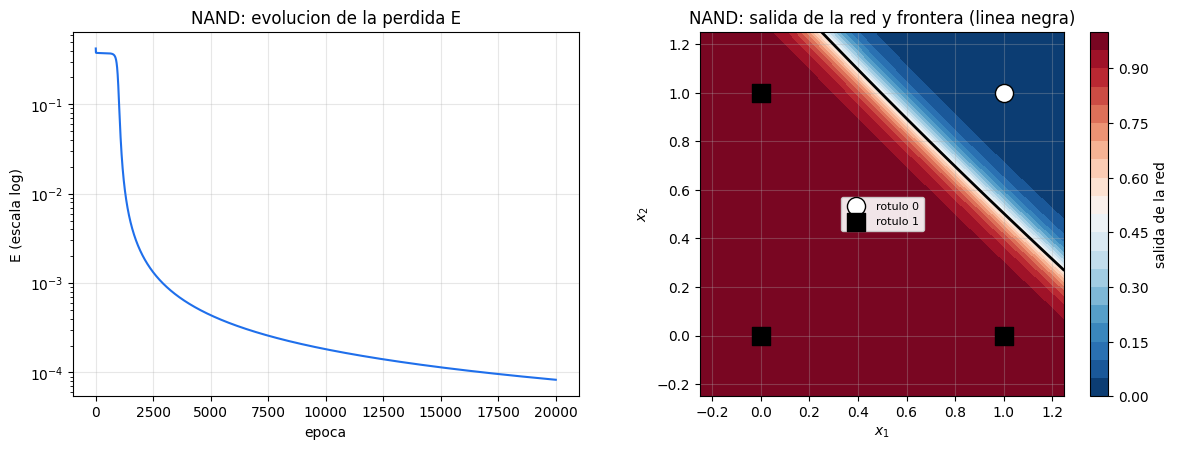

In [14]:
def superficie(W, b, Yr, titulo, ax):
    "Salida de la red en todo el cuadrado [-0.25, 1.25]^2 y frontera de decision (salida = 0.5)."
    g_ = np.linspace(-0.25, 1.25, 201)
    G1, G2 = np.meshgrid(g_, g_)
    malla = np.vstack([G1.ravel(), G2.ravel()])
    S = propaga(malla, W, b)[0][-1].reshape(G1.shape)
    im = ax.contourf(G1, G2, S, levels=np.linspace(0, 1, 21), cmap="RdBu_r")
    ax.contour(G1, G2, S, levels=[0.5], colors="k", linewidths=2)
    for y, mk, et in ((0, "o", "rotulo 0"), (1, "s", "rotulo 1")):
        sel = Yr.ravel() == y
        ax.scatter(X_gate[0, sel], X_gate[1, sel], marker=mk, c="white" if y == 0 else "black",
                   edgecolors="k", s=170, label=et, zorder=3)
    ax.legend(loc="center", fontsize=8, framealpha=0.9)
    ax.set_title(titulo); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_aspect("equal")
    return im

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].semilogy(hist_nand, color="#1f6feb")
ax[0].set_title("NAND: evolucion de la perdida E"); ax[0].set_xlabel("epoca"); ax[0].set_ylabel("E (escala log)")
im = superficie(W_nand, b_nand, Y_nand, "NAND: salida de la red y frontera (linea negra)", ax[1])
fig.colorbar(im, ax=ax[1], label="salida de la red")
plt.tight_layout(); plt.show()

La frontera de decisión de la NAND es prácticamente una recta que deja el punto $(1,1)$ de un lado y los otros tres del otro, como corresponde a un problema linealmente separable.

## 8. Red entrenada para la compuerta XOR

Se usa exactamente la misma red, con los mismos hiperparámetros y la misma semilla. Solo cambian los rótulos.

Compuerta XOR
  x1  x2   rotulo   salida red  clase      error
   0   0        0     0.006085      0  -6.09e-03
   0   1        1     0.993930      1   6.07e-03
   1   0        1     0.993150      1   6.85e-03
   1   1        0     0.005826      0  -5.83e-03
Aciertos: 4/4    Perdida final E = 7.74e-05


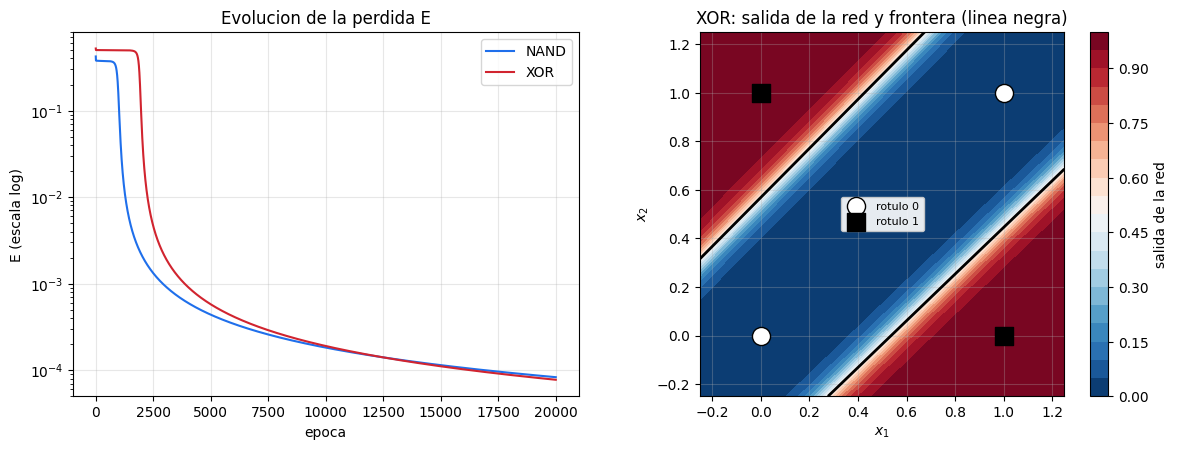

In [15]:
W_xor, b_xor, hist_xor = entrena(X_gate, Y_xor, NN, ETA, EPOCAS, SEMILLA)
tabla_resultados(X_gate, Y_xor, W_xor, b_xor, "XOR")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].semilogy(hist_nand, label="NAND", color="#1f6feb")
ax[0].semilogy(hist_xor,  label="XOR",  color="#d1242f")
ax[0].set_title("Evolucion de la perdida E"); ax[0].set_xlabel("epoca"); ax[0].set_ylabel("E (escala log)"); ax[0].legend()
im = superficie(W_xor, b_xor, Y_xor, "XOR: salida de la red y frontera (linea negra)", ax[1])
fig.colorbar(im, ax=ax[1], label="salida de la red")
plt.tight_layout(); plt.show()

La curva de la XOR tiene una **meseta** al comienzo: durante cerca de 2 000 épocas la pérdida se mantiene en $E \approx 0.5$, que es lo que se obtiene cuando la red responde 0.5 a los cuatro patrones. Es el periodo en que la red aún no ha encontrado cómo reorganizar los datos en las capas ocultas; cuando lo hace, la pérdida cae cuatro órdenes de magnitud en pocas centenas de épocas. La NAND muestra una meseta más corta, de unas 1 000 épocas.

La frontera de decisión de la XOR ya no es una recta sino **dos rectas paralelas**: la franja diagonal que contiene a $(0,0)$ y $(1,1)$ se clasifica como 0, y las dos regiones exteriores, donde están $(0,1)$ y $(1,0)$, como 1. Una neurona individual no puede producir esa forma.

### 8.1 Qué hacen las capas ocultas

Para ver cómo la red resuelve un problema no separable, se examinan las activaciones de cada capa para los cuatro patrones. En la segunda capa oculta los patrones deberían quedar dispuestos de forma que un único plano (la neurona de salida) los separe.

Capa oculta 1 (filas = neuronas, columnas = patrones 00, 01, 10, 11)
[[0.066 0.885 0.001 0.06 ]
 [0.917 0.999 0.098 0.934]
 [0.721 0.719 0.788 0.786]] 

Capa oculta 2 (filas = neuronas, columnas = patrones 00, 01, 10, 11)
[[0.264 0.774 0.741 0.262]
 [0.887 0.105 0.102 0.892]
 [0.66  0.318 0.313 0.654]] 



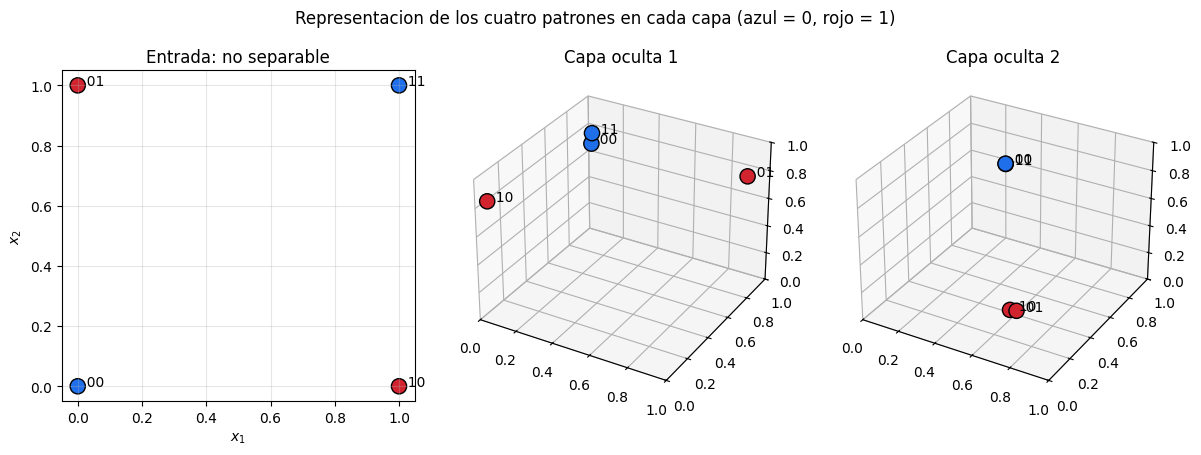

In [16]:
A, Z = propaga(X_gate, W_xor, b_xor)
for k, nombre in ((1, "Capa oculta 1"), (2, "Capa oculta 2")):
    print(nombre, "(filas = neuronas, columnas = patrones 00, 01, 10, 11)")
    print(np.round(A[k], 3), "\n")

fig = plt.figure(figsize=(12, 4.6))
for j, k in enumerate((0, 1, 2)):
    ax = fig.add_subplot(1, 3, j + 1, projection=None if k == 0 else "3d")
    colores = ["#1f6feb" if y == 0 else "#d1242f" for y in Y_xor.ravel()]
    if k == 0:
        ax.scatter(A[0][0], A[0][1], c=colores, s=120, edgecolors="k")
        ax.set_title("Entrada: no separable"); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    else:
        ax.scatter(A[k][0], A[k][1], A[k][2], c=colores, s=120, edgecolors="k", depthshade=False)
        ax.set_title(f"Capa oculta {k}")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_zlim(0, 1)
    for i, et in enumerate(["00", "01", "10", "11"]):
        pos = (A[0][0, i], A[0][1, i]) if k == 0 else (A[k][0, i], A[k][1, i], A[k][2, i])
        ax.text(*pos, "  " + et, fontsize=10)
plt.suptitle("Representacion de los cuatro patrones en cada capa (azul = 0, rojo = 1)")
plt.tight_layout(); plt.show()

En la entrada, los patrones con salida 1 (rojos) están en esquinas opuestas. La primera capa oculta ya los reubica, y en la segunda los patrones de cada clase prácticamente coinciden en un mismo punto: $00$ y $11$ quedan juntos en un extremo, y $01$ y $10$ en el otro. La primera neurona de esa capa, por ejemplo, vale cerca de 0.26 para los dos azules y cerca de 0.76 para los dos rojos. La neurona de salida, que por sí sola solo puede trazar un plano, ya puede separarlos. Esta es la idea central del capítulo: la función de activación no lineal y las capas ocultas le dan a la red la capacidad de cambiar la representación de los datos.

La red entrenada llega por su cuenta al mismo resultado que la construcción a mano de la sección 3.4, pero por un camino distinto: allí las dos neuronas ocultas eran una OR y una NAND reconocibles, mientras que aquí las tres neuronas de cada capa reparten el trabajo sin corresponder a compuertas con nombre.

## 9. Por qué hacen falta las capas ocultas

Se entrena una sola neurona (topología 2‑1, sin capas ocultas) con el mismo algoritmo, para comprobar lo que afirmaron Minsky y Papert.

In [17]:
print(f"{'Compuerta':<10}{'salidas de una sola neurona tras 20 000 epocas':<52}{'E final':>9}")
for nombre, Yg in (("NAND", Y_nand), ("XOR", Y_xor)):
    W1n, b1n, h1n = entrena(X_gate, Yg, [2, 1], ETA, EPOCAS, SEMILLA)
    s = propaga(X_gate, W1n, b1n)[0][-1].ravel()
    print(f"{nombre:<10}{str(np.round(s, 4)):<52}{h1n[-1]:>9.4f}")

Compuerta salidas de una sola neurona tras 20 000 epocas        E final


NAND      [1.     0.9836 0.9836 0.0194]                          0.0005


XOR       [0.5 0.5 0.5 0.5]                                      0.5000


La neurona única aprende la NAND sin dificultad, lo que concuerda con que la sección 3.1 la resolviera con una sola neurona si se le permite el peso adecuado. En la XOR, en cambio, se estanca respondiendo 0.5 a los cuatro patrones ($E = 0.5$): ninguna recta separa las clases, y la solución de mínima pérdida cuadrática para una frontera lineal es no comprometerse con ninguna. Con dos capas ocultas el mismo algoritmo resuelve el problema.

## 10. Robustez del entrenamiento

Un solo entrenamiento exitoso puede ser cuestión de suerte en la inicialización. Se repite el entrenamiento con **20 semillas** distintas en ocho configuraciones: las dos compuertas, las dos versiones de la derivada de la sigmoide y dos rangos de inicialización, el $[0,1]$ y el $[-1,1]$. Se considera que la red **aprendió** la compuerta si las cuatro salidas quedan a menos de 0.1 de su rótulo.

La celda tarda entre cinco y siete minutos.

In [18]:
import time
t0 = time.time()
N_SEM = 20
filas, fallos_correcta = [], []
for nombre, Yg in (("NAND", Y_nand), ("XOR", Y_xor)):
    for rango in ((0.0, 1.0), (-1.0, 1.0)):
        for etiqueta_der, der in (("sig*(1-sig)", dSig), ("sig*sig (cap.)", dSig_doc)):
            exitos, finales = 0, []
            for s in range(N_SEM):
                W, b, h = entrena(X_gate, Yg, NN, ETA, EPOCAS, semilla=100 + s, rango=rango, derivada=der)
                salida = propaga(X_gate, W, b)[0][-1]
                ok = np.all(np.abs(Yg - salida) < 0.1)
                exitos += ok
                finales.append(h[-1])
                if not ok and der is dSig:
                    fallos_correcta.append((nombre, rango, 100 + s, salida.ravel(), h[-1]))
            filas.append((nombre, rango, etiqueta_der, exitos, np.median(finales)))

print(f"{'Compuerta':<10}{'Inicializacion':<16}{'Derivada':<17}{'Aprendio':>10}{'E final (mediana)':>20}")
print("-" * 73)
for f in filas:
    print(f"{f[0]:<10}{str(list(f[1])):<16}{f[2]:<17}{f[3]:>7}/{N_SEM}{f[4]:>20.2e}")

print("\nFallos con la derivada correcta (compuerta, inicializacion, semilla, salidas, E):")
for f in fallos_correcta:
    print(f"   {f[0]}  {list(f[1])}  semilla {f[2]}  salidas {np.round(f[3], 3)}  E = {f[4]:.3f}")
print(f"\nTiempo: {time.time() - t0:.0f} s")

Compuerta Inicializacion  Derivada           Aprendio   E final (mediana)
-------------------------------------------------------------------------
NAND      [0.0, 1.0]      sig*(1-sig)           20/20            7.39e-05
NAND      [0.0, 1.0]      sig*sig (cap.)         6/20            3.75e-01
NAND      [-1.0, 1.0]     sig*(1-sig)           20/20            5.55e-05
NAND      [-1.0, 1.0]     sig*sig (cap.)        17/20            2.55e-03
XOR       [0.0, 1.0]      sig*(1-sig)           20/20            9.26e-05
XOR       [0.0, 1.0]      sig*sig (cap.)         0/20            5.00e-01
XOR       [-1.0, 1.0]     sig*(1-sig)           19/20            8.96e-05
XOR       [-1.0, 1.0]     sig*sig (cap.)         0/20            5.00e-01

Fallos con la derivada correcta (compuerta, inicializacion, semilla, salidas, E):
   XOR  [-1.0, 1.0]  semilla 113  salidas [0.013 0.5   0.988 0.5  ]  E = 0.251

Tiempo: 265 s


Los resultados llevan a tres observaciones:

1. **Con la derivada correcta, las dos compuertas se aprenden de forma confiable**: 79 de las 80 corridas llegan a la solución. El único fallo es de la XOR y corresponde a un mínimo local clásico de este problema: la red resuelve bien dos patrones y responde 0.5 a los otros dos, con $E = 0.25$. Reiniciar el entrenamiento con otra semilla lo resuelve.
2. **Con la derivada del programa de clase, la XOR no se aprende en ninguna de las 40 corridas**: la pérdida final tiene una mediana de $E = 0.5$, el valor que corresponde a responder 0.5 a los cuatro patrones. La NAND se aprende solo en una parte de las corridas y con un error final mucho mayor. El problema pasa inadvertido en el Ejemplo 1 del capítulo porque allí basta con acercar dos salidas a sus rótulos; cuando las capas ocultas tienen que construir una representación nueva, un gradiente mal calculado no lo permite.
3. **El rango de inicialización importa poco cuando el gradiente es correcto** (20/20 y 19/20 en la XOR, 20/20 en ambos casos para la NAND). Con la derivada del capítulo sí pesa: la NAND se aprende en 17 de 20 corridas con $[-1,1]$ y en solo 6 de 20 con $[0,1]$. Iniciar en $[-1,1]$ da desde el principio pesos de ambos signos, lo que diferencia más a las neuronas entre sí.

## 11. Conclusiones

**Sobre el procedimiento del capítulo (sección 3).** Se reprodujo el procedimiento de la sección 5.3 con el que el capítulo construye las compuertas escogiendo los pesos a mano: AND, OR y NOT con una sola neurona; la red de dos capas de la figura 5.10, reproducida con sus once columnas y los mismos pesos $(-30, 20, 20)$ y $(10, -20)$; la NOR obtenida de la misma forma a partir de la OR; la red de dos salidas de la figura 5.11; y la XOR armada con esas mismas piezas, lo que muestra que basta una capa oculta para resolverla.

**Sobre las redes entrenadas.** Las dos redes solicitadas, con topología 2‑3‑3‑1 y entrenadas por retropropagación desde pesos aleatorios, aprenden sus compuertas: la NAND con salidas a menos de $10^{-2}$ de los rótulos y una frontera de decisión prácticamente recta, y la XOR con una frontera formada por dos rectas paralelas, que una neurona individual no puede producir. Con 20 semillas distintas, 79 de 80 entrenamientos llegaron a la solución. El análisis de las activaciones internas muestra el mecanismo: las capas ocultas reubican los cuatro patrones de modo que, al llegar a la neurona de salida, las dos clases quedan separables por un plano. La comparación con una sola neurona, que en la XOR se estanca en $E = 0.5$, reproduce la limitación señalada por Minsky y Papert.

**Sobre el programa de partida.** Se validó reproduciendo las cifras exactas del Ejemplo 1. Esa misma verificación puso en evidencia que la función `dSig` calcula $\sigma^2$ en lugar de $\sigma(1-\sigma)$. La prueba de gradiente confirma que con esa expresión la retropropagación no calcula el gradiente de la pérdida, y el experimento con 20 semillas muestra la consecuencia práctica: con ella la XOR no se aprende nunca. Con la derivada corregida, el propio Ejemplo 1 del capítulo reduce su error final unas cien veces.

**La diferencia entre construir y aprender.** El contraste entre la sección 3 y las secciones 7 y 8 es el que da sentido al ejercicio. Con pesos escogidos a mano, cada neurona tiene un significado claro y las compuertas se encadenan como en un circuito lógico. Con pesos aprendidos, la red llega a la misma función sin que ninguna neurona corresponda a una compuerta reconocible: el conocimiento queda repartido entre los 25 parámetros. Lo que el algoritmo de aprendizaje aporta es precisamente no tener que diseñar esa estructura de antemano.